Team image:(https://drive.google.com/file/d/10FEVc5x6a0931QvsITiOVwaWtVxk3vn6/view?usp=sharing)

#Group 12
Team members:
1.   171132 - Amani Koros - Q1-4
2.   189925 - Manvin Chager - Q5-7
3.   156691 - Asiya Abdalla - Q8-10
  





# Question 1
Downloading and loading dataset (Airplane_crashes_dataset)

In [ ]:
import pandas as pd
import kagglehub
import os

# Method 1: Manual Download and Upload of the dataset
# df_air = pd.read_csv("https://github.com/Amani-K-code/Data-Wrangling/blob/main/Airplane_Crashes_and_Fatalities_Since_1908.csv")

# Method 2: Downloading the dataset directly from Kaggle into Colab
path = kagglehub.dataset_download("saurograndi/airplane-crashes-since-1908")
print("The path to the dataset file: ", path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_air = pd.read_csv(os.path.join(path, csv_file))

100%|██████████| 564k/564k [00:00<00:00, 82.4MB/s]

Extracting files...
The path to the dataset file:  /root/.cache/kagglehub/datasets/saurograndi/airplane-crashes-since-1908/versions/4


# Question 2
Number of rows and Columns

In [ ]:
df_air.shape

(5268, 13)

# Question 3
Last 75 rows in the dataset

In [ ]:
df_air.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


# Question 4:
## Missing data

In [ ]:
# Checking to see whether it is correct that all the columns except the first have missing values as the question suggests.
df_air.isna().any()

,0
Date,False
Time,True
Location,True
Operator,True
Flight #,True
Route,True
Type,True
Registration,True
cn/In,True
Aboard,True


In [ ]:
df_air.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


## Handling Missing Data
Please refer to the above statistics for the reasons to the method choices

In [ ]:
df_air["Time"] = df_air["Time"].fillna("Unknown")                       # TIME - 2219 :- Fill the cells with the 'Unknown' place holder since it is a text field

df_air = df_air.dropna(subset = ["Location"])                           # LOCATION - 20:- since they are a few data cells dropping the rows looses minimal data compared to the dataset size.

df_air["Operator"] = df_air["Operator"].fillna("Unknown")               # OPERATOR - 18:- since they are a few data cells with missing values we replaced the missing data with the place holder 'Unknown' since its text

df_air = df_air.drop(columns=["Flight #"])                              # FLIGHT# - 4199:- since the number of data cells with missing data is very close to the dataset size then we decided to drop the whole column since it hardly carries any usable information.

df_air["Route"] = df_air["Route"].fillna("Unknown")                     # ROUTE - 1707:- since the route is specific text and cannot be made up or given a value '0' we used an "Unknown" place holder

df_air["Type"] = df_air["Type"].fillna("Unknown")                       # TYPE - 27:- since the type of the aircraft is unknown we saw it fit to just fill the missing data with unknown placeholders

df_air["Registration"] = df_air["Registration"].fillna("Unknown")       # REGISTRATION - 335:- since this is a unique identifier of the place then the number cannot be made up or assumed, therefore we also put an Unknown placeholder for this.

df_air["cn/In"] = df_air["cn/In"].fillna("Unknown")                     # cn/In - 1228:- this is also a unique identifier and hence is also given an "Unknown" placeholder

df_air["Aboard"] = df_air["Aboard"].fillna(df_air['Aboard'].median())   # ABOARD - 22:- since the number of missing data cells are few , we decided to get the median of most of the planes number of passengers aboard and use that median as a placeholder (Large passenger planes skew the average)

df_air = df_air.dropna(subset = ["Fatalities"])                         # FATALITIES - 12:- since it is a very small amount of data cells with missing data we drop the few

df_air["Ground"] = df_air["Ground"].fillna(0)                           # GROUND - 22:- Most crashes have zzero ground fatailities, therefore we fill the missing data cells with '0'

df_air["Summary"] = df_air["Summary"].fillna("No available Summary")    # SUMMARY - 390:- Since this is a free text decription we put a "No available summary" placeholder

#Question 5: reate a new dataframe from the raw/uncleaned data called
‘fatality_locations’ with the following columns: ‘Date’,
‘Location’, ‘Aboard’, ‘Fatalities’.




In [ ]:
df_raw = pd.read_csv(os.path.join(path, csv_file))

fatality_locations = df_raw[['Date','Location','Aboard','Fatalities']]
fatality_locations

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0
...,...,...,...,...
5263,05/20/2009,"Near Madiun, Indonesia",112.0,98.0
5264,05/26/2009,"Near Isiro, DemocratiRepubliCongo",4.0,4.0
5265,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",228.0,228.0
5266,06/07/2009,"Near Port Hope Simpson, Newfoundland, Canada",1.0,1.0


#question 6: Determine the date of the highest number of recorded fatalities from this new
dataframe.

In [ ]:
fatality_locations['Fatalities'].max()
fatality_locations[fatality_locations['Fatalities']== 583]

,Date,Location,Aboard,Fatalities
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0


#question 7: Compare the number of passengers aboard to the number of fatalities per crash. Are
there any recorded crashes where there were no fatalities? If so, how many?


In [ ]:
fatality_locations[fatality_locations['Fatalities'] == 0]

,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0


In [ ]:
(fatality_locations['Fatalities'] == 0).sum()

np.int64(58)

#qn 8: In the ‘fatality_locations’ dataframe, the location column has data items represented as ‘Region, U.S. State/Country’. Split this column to have two columns of regions and states/countries.

In [ ]:
import pandas as pd

fatality_locations = df_raw[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

split_data = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)

fatality_locations['Region'] = split_data[0].str.strip()
fatality_locations['Country_State'] = split_data[1].str.strip()

fatality_locations['Country_State'] = fatality_locations['Country_State'].fillna(fatality_locations['Region'])

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,Country_State
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,Over the North Sea
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


#Qn9.Order the dataframe by the number of fatalities from highest to lowest and select the first 100.

In [ ]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,Country_State
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


#Qn10. Generate a pie chart that shows the distribution of the top 25 number of fatalities per country/U.S. State. [Hint: charts can be generated from the seaborn library]

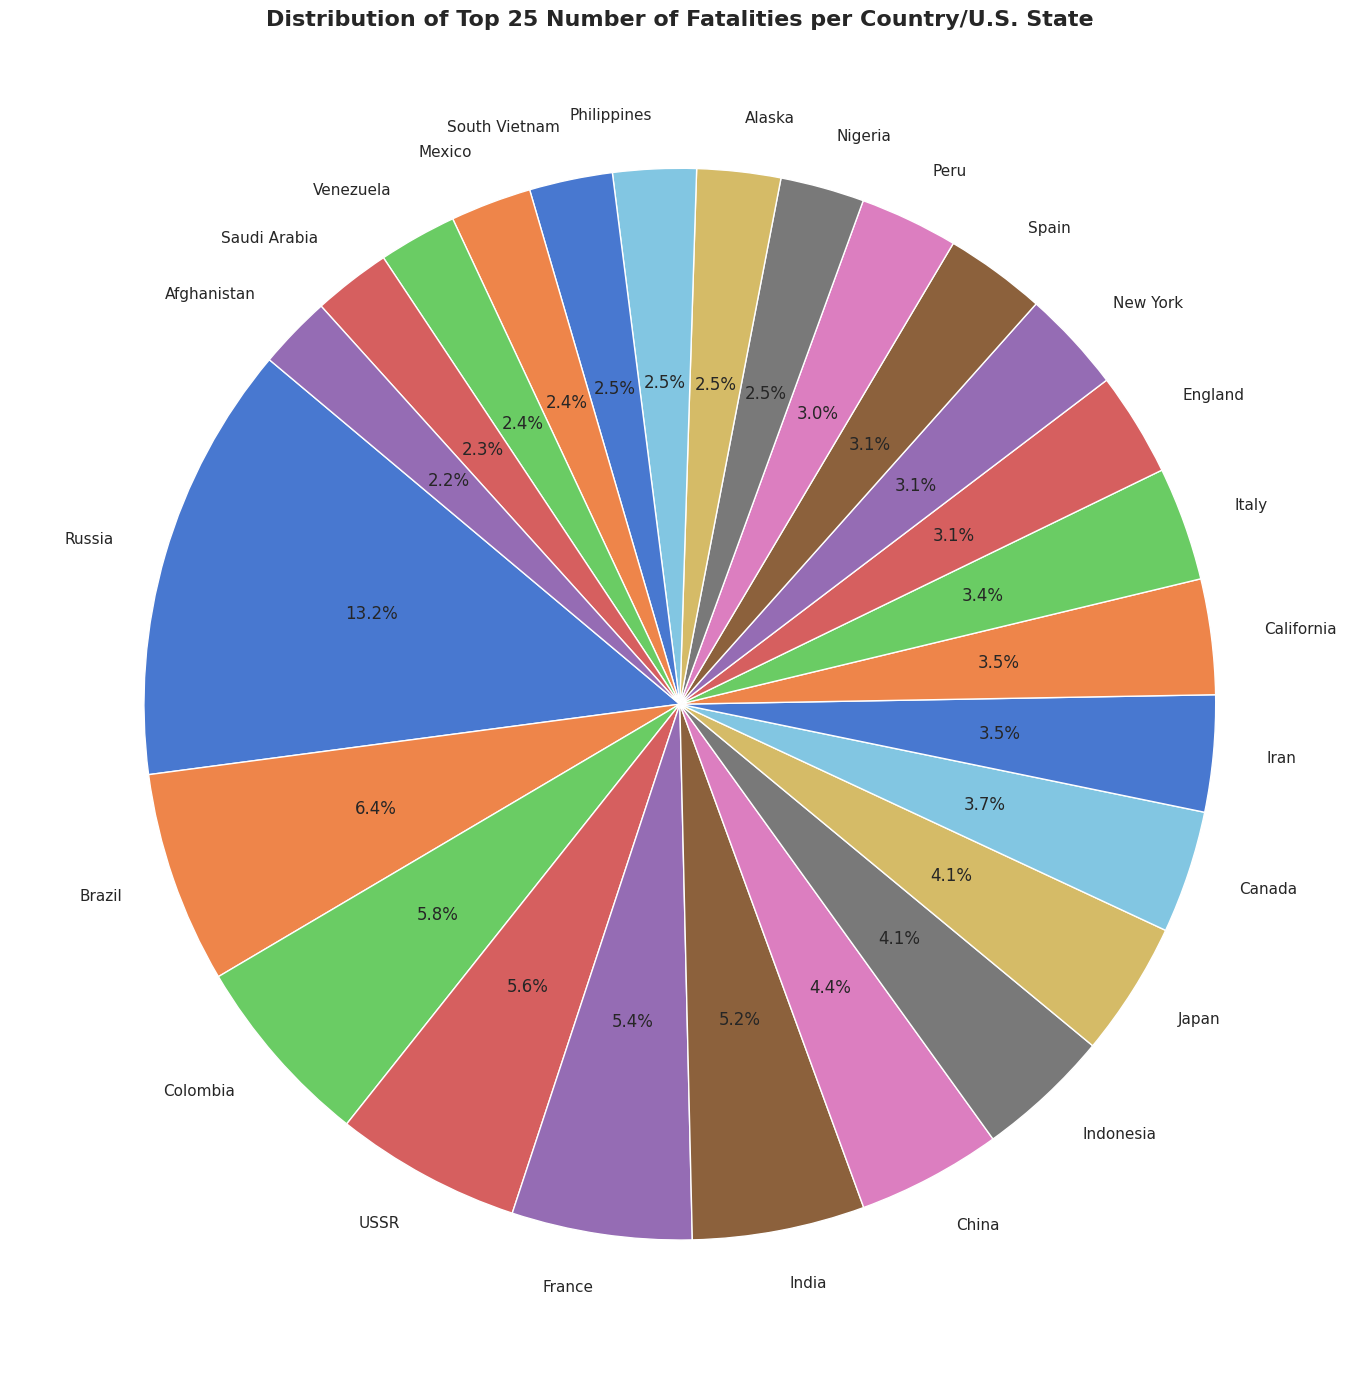

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

top_25_fatalities = fatality_locations.groupby('Country_State')['Fatalities'].sum().nlargest(25)

plt.figure(figsize=(14, 14))
plt.pie(
    top_25_fatalities,
    labels=top_25_fatalities.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("muted", len(top_100_fatalities))
)

plt.title('Distribution of Top 25 Number of Fatalities per Country/U.S. State', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()